# 02 · Exploração e teste da hipótese

**Hipótese:** crime e preço de imóvel têm correlação negativa, ou seja, bairro mais violento, metro quadrado mais barato.

In [3]:
import gzip
import json
import re
import unicodedata
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from scipy import stats

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
CACHE = RAIZ / "data" / "SP" / "cache"

crimes = pd.read_parquet(CACHE / "crimes_sp.parquet")
itbi = pd.read_parquet(CACHE / "itbi_sp.parquet")
dicionario_ruas = pd.read_parquet(CACHE / "dicionario_ruas.parquet")
setor_para_distrito = pd.read_parquet(CACHE / "setor_para_distrito.parquet")

print(f"crimes    {len(crimes):>9,} ocorrências")
print(f"itbi      {len(itbi):>9,} transações")
print(f"ruas      {dicionario_ruas['rua_key'].nunique():>9,} no dicionário "
      f"({len(dicionario_ruas):,} linhas, cidade-toda + por distrito)")

crimes    2,214,258 ocorrências
itbi        943,536 transações
ruas         48,214 no dicionário (98,722 linhas, cidade-toda + por distrito)


### Estilo dos gráficos

Paleta fixa nos três notebooks:
- Azul = série única; laranja/aqua só com mais de uma série, ordem fixa.
- Magnitude: rampa de uma cor (nunca arco-íris — sem ordem perceptual).
- Crime e preço: rampas diferentes (azul/laranja), pra não confundir escalas.
- Polaridade (correlação, −1 a +1): divergente azul↔vermelho, cinza no meio.

In [4]:
AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SUPERFICIE, TINTA, TINTA2, MUDO, GRADE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

RAMPA_CRIME = LinearSegmentedColormap.from_list("crime", ["#cde2fb", "#5598e7", "#256abf", "#0d366b"])
RAMPA_PRECO = LinearSegmentedColormap.from_list("preco", ["#fde8dc", "#f29b70", "#eb6834", "#8f3414"])
DIVERGENTE = LinearSegmentedColormap.from_list("div", [AZUL, "#f0efec", "#e34948"])
ESCADA_AZUL = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "figure.dpi": 110, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelcolor": TINTA2, "axes.labelsize": 10,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRADE, "grid.linewidth": 0.8,
    "xtick.color": MUDO, "ytick.color": MUDO, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "lines.linewidth": 2, "lines.markersize": 8,
})
sns.set_palette([AZUL, LARANJA, AQUA])


def reais(valor, _=None):
    return f"R$ {valor:,.0f}".replace(",", ".")


FORMATO_REAIS = FuncFormatter(reais)

## 1 · Deflacionando para reais constantes

- Base cobre 2022–2026; sem corrigir inflação, parte da variação de preço seria só IPCA.
- Fonte: **IPCA oficial**, API do IBGE (tabela 1737) — número-índice (2266) e variação mensal (63). Salvo em `ipca_ibge.csv`.
- Fator = índice do mês de referência ÷ índice do mês da transação (não encadeia variações arredondadas — acumula erro).
- Verificação: IPCA anual por dois caminhos independentes (razão de índices × produto de variações) — se concordam, a série foi lida certo.

In [5]:
URL_IPCA = (
    "https://servicodados.ibge.gov.br/api/v3/agregados/1737"
    "/periodos/202101-202612/variaveis/2266|63?localidades=N1[all]"
)
ARQUIVO_IPCA = CACHE / "ipca_ibge.csv"
VARIAVEIS_IPCA = {"2266": "indice", "63": "variacao_pct"}


def baixa_ipca():
    pedido = urllib.request.Request(URL_IPCA, headers={"Accept-Encoding": "identity"})
    with urllib.request.urlopen(pedido, timeout=60) as resposta:
        conteudo = resposta.read()
    if conteudo[:2] == b"\x1f\x8b":
        conteudo = gzip.decompress(conteudo)
    bruto = json.loads(conteudo.decode("utf-8"))
    series = {
        VARIAVEIS_IPCA[v["id"]]: v["resultados"][0]["series"][0]["serie"] for v in bruto
    }
    return pd.DataFrame(series).rename_axis("periodo").reset_index()


def carrega_ipca():
    if ARQUIVO_IPCA.exists():
        print(f"IPCA: lendo de {ARQUIVO_IPCA.name}")
        tabela = pd.read_csv(ARQUIVO_IPCA, dtype={"periodo": str})
    else:
        tabela = baixa_ipca()
        tabela.to_csv(ARQUIVO_IPCA, index=False)
        print(f"IPCA: baixado da API do IBGE (tabela 1737) e salvo em {ARQUIVO_IPCA.name}")
    for coluna in VARIAVEIS_IPCA.values():
        tabela[coluna] = pd.to_numeric(tabela[coluna], errors="coerce")
    tabela["mes"] = tabela["periodo"].str[:4] + "-" + tabela["periodo"].str[4:]
    return tabela.dropna(subset=["indice"]).sort_values("mes").reset_index(drop=True)


ipca = carrega_ipca()
ipca["fator"] = ipca["indice"].iloc[-1] / ipca["indice"]
MES_REFERENCIA = ipca["mes"].iloc[-1]

print(f"Série oficial: {len(ipca)} meses, de {ipca['mes'].iloc[0]} a {MES_REFERENCIA}")
print(f"Reais constantes de: {MES_REFERENCIA}")
print(f"Fator no mês mais antigo ({ipca['mes'].iloc[0]}): {ipca['fator'].iloc[0]:.4f}\n")

anual = ipca.assign(ano=ipca["mes"].str[:4]).groupby("ano").agg(
    meses=("variacao_pct", "size"),
    indice_dez=("indice", "last"),
    por_encadeamento=("variacao_pct", lambda v: ((1 + v / 100).prod() - 1) * 100),
)
anual["por_numero_indice"] = (anual["indice_dez"] / anual["indice_dez"].shift() - 1) * 100
anual["diferença"] = anual["por_encadeamento"] - anual["por_numero_indice"]

anual[["meses", "por_encadeamento", "por_numero_indice", "diferença"]].style.format(
    {"por_encadeamento": "{:.2f}%", "por_numero_indice": "{:.2f}%", "diferença": "{:+.3f} pp"},
    na_rep="—",
).set_caption("IPCA acumulado por ano, calculado de duas formas independentes")

IPCA: lendo de ipca_ibge.csv
Série oficial: 68 meses, de 2021-01 a 2026-08
Reais constantes de: 2026-08
Fator no mês mais antigo (2021-01): 1.3693



,meses,por_encadeamento,por_numero_indice,diferença
ano,,,,
2021,12,10.06%,—,—
2022,12,5.78%,5.79%,-0.000 pp
2023,12,4.62%,4.62%,-0.000 pp
2024,12,4.83%,4.83%,+0.000 pp
2025,12,4.26%,4.26%,+0.000 pp
2026,8,3.11%,3.11%,-0.000 pp


## 2 · Agrupando as 24 naturezas criminais

- 24 naturezas → 4 grupos: trânsito/culposo, patrimonial sem violência (furto), violento (roubo, com vítima), outros.
- Ordem importa: trânsito/culposo capturado **primeiro** (senão "homicídio"/"lesão corporal" no nome contaria como violência).
- Eixo da análise: furto mede fluxo de gente; roubo mede risco.

In [6]:
VIOLENTOS = ("ROUBO", "LATROCINIO", "HOMICIDIO", "LESAO CORPORAL", "ESTUPRO", "EXTORSAO", "SEQUESTRO")


def grupo_crime(natureza):
    if "ACIDENTE DE TRANSITO" in natureza or "CULPOS" in natureza:
        return "trânsito / culposo"
    if natureza.startswith("FURTO"):
        return "patrimonial sem violência"
    if any(termo in natureza for termo in VIOLENTOS):
        return "violento"
    return "outros"


crimes["grupo"] = crimes["natureza"].astype(str).map(grupo_crime)

(
    crimes.groupby(["grupo", "natureza"], observed=True)
    .size()
    .rename("ocorrências")
    .reset_index()
    .sort_values(["grupo", "ocorrências"], ascending=[True, False])
    .set_index(["grupo", "natureza"])
)

ocorrências
grupo                     natureza                                                    
outros                    TRAFICO DE ENTORPECENTES                               22998
                          PORTE DE ENTORPECENTES                                  4247
                          APREENSAO DE ENTORPECENTES                              4014
                          PORTE DE ARMA                                           3883
patrimonial sem violência FURTO - OUTROS                                       1129990
                          FURTO DE VEICULO                                      187010
                          FURTO DE CARGA                                           680
trânsito / culposo        LESAO CORPORAL CULPOSA POR ACIDENTE DE TRANSITO        62539
                          LESAO CORPORAL CULPOSA - OUTRAS                         2756
                          HOMICIDIO CULPOSO POR ACIDENTE DE TRANSITO              2655
                          LESAO CORPORAL CULPOSA  OUTRAS                           674
                          HOMICIDIO CULPOSO OUTROS                                 115
                          HOMICIDIO DOLOSO POR ACIDENTE DE TRANSITO                 39
violento                  ROUBO - OUTROS                                        534361
                          LESAO CORPORAL DOLOSA                                 170581
                          ROUBO DE VEICULO                                       58276
                          ROUBO DE CARGA                                         10649
                          ESTUPRO DE VULNERAVEL                                   9224
                          ESTUPRO                                                 3331
                          TENTATIVA DE HOMICIDIO                                  3145
                          HOMICIDIO DOLOSO                                        2277
                          EXTORSAO MEDIANTE SEQUESTRO                              452
                          LATROCINIO                                               217
                          LESAO CORPORAL SEGUIDA DE MORTE                          130
                          ROUBO A BANCO                                             15

## 3 · Localizando cada transação

`Bairro` do ITBI só vem preenchido em 61% das linhas. Três fontes, em ordem:

| prioridade | fonte | cobertura | por quê |
|---|---|---|---|
| 1ª | `Bairro` do próprio ITBI | 38,8% | fonte oficial |
| 2ª | propagação por CEP | 92,6% | CEP ≈ quadra em SP |
| 3ª | dicionário de ruas (≥ 20 ocorrências) | 79,8% | só o que sobrou |
| | **combinado** | **97,0%** | |

- **Caso Melo Alves:** a rua existe duas vezes em SP (Jardins e Jardim Monte Verde); só 9 ocorrências de crime, todas no sul. O dicionário etiquetou 255 transações dos Jardins com o bairro errado — por isso CEP vem antes da rua.
- **Via longa:** 4,36% das transações dependem só do dicionário de ruas; 23% delas em ruas com pureza < 70% (ex. `RAPOSO TAVARES`, 26,6%). Corrigido em `01_preparacao.ipynb` desambiguando por distrito (linha `dicionário de ruas, por distrito` na cobertura abaixo).
- **Coordenada:** vem do dicionário de ruas, só aceita se o bairro modal da rua concordar com o bairro final; senão usa o centro do bairro.

In [7]:
ABREVIACOES_BAIRRO = {
    "VL": "VILA", "JD": "JARDIM", "PQ": "PARQUE", "CJ": "CONJUNTO", "CID": "CIDADE",
    "S": "SAO", "STO": "SANTO", "STA": "SANTA", "CH": "CHACARA", "AL": "ALTO",
}
VOCABULARIO_BAIRROS = set(crimes["bairro"].dropna().astype(str).unique())
MINIMO_OCORRENCIAS_RUA = 20


def normaliza_bairro(nome):
    texto = unicodedata.normalize("NFKD", str(nome)).encode("ascii", "ignore").decode().upper()
    palavras = re.sub(r"[^A-Z0-9 ]", " ", texto).split()
    return " ".join(ABREVIACOES_BAIRRO.get(p, p) for p in palavras) or None


def bairro_por_cep(tabela):
    return (
        tabela.dropna(subset=["bairro_declarado"])
        .groupby(["cep_txt", "bairro_declarado"])
        .size()
        .rename("n")
        .reset_index()
        .sort_values("n")
        .groupby("cep_txt")["bairro_declarado"]
        .last()
        .rename("bairro_cep")
    )


def centro_dos_bairros():
    centro = (
        crimes.dropna(subset=["lat", "lon"])
        .groupby("bairro", observed=True)[["lat", "lon"]]
        .median()
    )
    centro.index = centro.index.astype(str)
    return centro


def localiza(transacoes):
    traduzido = {v: normaliza_bairro(v) for v in transacoes["bairro_itbi"].dropna().unique()}
    tabela = transacoes.assign(
        cep_txt=transacoes["cep"].astype("Int64").astype(str).str.zfill(8),
        bairro_declarado=transacoes["bairro_itbi"].map(traduzido),
        setor_fiscal=transacoes["setor_fiscal"].astype(str),
    )
    tabela["bairro_declarado"] = tabela["bairro_declarado"].where(
        tabela["bairro_declarado"].isin(VOCABULARIO_BAIRROS)
    )
    tabela = tabela.merge(setor_para_distrito[["setor_fiscal", "distrito"]], on="setor_fiscal", how="left")
    tabela = tabela.join(bairro_por_cep(tabela), on="cep_txt")

    confiaveis = dicionario_ruas[dicionario_ruas["n_ocorrencias"].ge(MINIMO_OCORRENCIAS_RUA)]
    por_distrito = confiaveis[confiaveis["distrito"].notna()].set_index(["rua_key", "distrito"])
    cidade_toda = confiaveis[confiaveis["distrito"].isna()].set_index("rua_key")

    tabela = tabela.join(por_distrito[["bairro", "lat", "lon"]].add_suffix("_local"), on=["rua_key", "distrito"])
    tabela = tabela.join(cidade_toda[["bairro", "lat", "lon"]].add_suffix("_cidade"), on="rua_key")
    tabela["bairro_rua"] = tabela["bairro_local"].fillna(tabela["bairro_cidade"])

    tabela["bairro"] = tabela["bairro_declarado"].fillna(tabela["bairro_cep"]).fillna(tabela["bairro_rua"])

    centro = centro_dos_bairros()
    rua_concorda = tabela["bairro_rua"].eq(tabela["bairro"])
    for eixo in ["lat", "lon"]:
        rua_coord = tabela[f"{eixo}_local"].fillna(tabela[f"{eixo}_cidade"])
        tabela[eixo] = rua_coord.where(rua_concorda, tabela["bairro"].map(centro[eixo]))

    cobertura = {
        "campo Bairro do ITBI": tabela["bairro_declarado"].notna().mean(),
        "propagação por CEP": tabela["bairro_cep"].notna().mean(),
        "dicionário de ruas": tabela["bairro_rua"].notna().mean(),
        "dicionário de ruas, por distrito": tabela["bairro_local"].notna().mean(),
        "combinado": tabela["bairro"].notna().mean(),
    }
    descartaveis = [
        "cep_txt", "bairro_declarado", "bairro_cep", "bairro_rua", "distrito",
        "bairro_local", "bairro_cidade", "lat_local", "lon_local", "lat_cidade", "lon_cidade",
    ]
    return tabela.drop(columns=descartaveis), cobertura


itbi, cobertura_bairro = localiza(itbi)

print(f"coordenada disponível em {itbi['lat'].notna().mean():.1%} das transações")
print("\nchecagem do caso que motivou a correção — RUA MELO ALVES:")
print(itbi[itbi["rua_key"] == "MELO ALVES"]["bairro"].value_counts().head(4).to_string())

pd.Series(cobertura_bairro, name="cobertura").to_frame().style.format({"cobertura": "{:.1%}"})

coordenada disponível em 96.7% das transações

checagem do caso que motivou a correção — RUA MELO ALVES:
bairro
CERQUEIRA CESAR    513
JARDIM AMERICA      29
JARDIM PAULISTA      2
JARDINS              2


,cobertura
campo Bairro do ITBI,38.9%
propagação por CEP,92.6%
dicionário de ruas,79.8%
"dicionário de ruas, por distrito",63.6%
combinado,97.0%


## 4 · Filtros: de guia de ITBI a preço real por metro quadrado

- **2022–2026**: escrituras vêm desde 1994; sem crime pra comparar antes de 2022 (0,7% das linhas saem).
- **Proporção transmitida = 100%**: abaixo disso é fração ideal de lote-matriz — área construída seria do prédio inteiro, não do imóvel vendido. Filtro mais caro (~metade).
- **Exclui vaga de garagem**: infla o R$/m² do bairro.
- **Mês coberto pelo IPCA**: meses recentes sem índice ainda são descartados, não estimados.

In [8]:
MESES_COM_IPCA = set(ipca["mes"])

FILTROS = [
    ("guias de ITBI (tudo)", lambda d: d),
    ("transação entre 2022 e 2026", lambda d: d[d["ano"].between(2022, 2026)]),
    ("natureza = compra e venda", lambda d: d[d["natureza_transacao"].astype(str).str.startswith("1.")]),
    ("100% do imóvel transmitido", lambda d: d[d["proporcao_transmitida"] == 100]),
    ("padrão residencial", lambda d: d[d["padrao_desc"].astype(str).str.startswith("RESIDENCIAL")]),
    ("exclui vaga de garagem", lambda d: d[~d["uso_desc"].astype(str).str.contains("GARAGEM")]),
    ("área construída e valor > 0", lambda d: d[d["area_construida"].gt(0) & d["valor_transacao"].gt(0)]),
    ("bairro identificado", lambda d: d[d["bairro"].notna()]),
    ("mês coberto pela série do IPCA", lambda d: d[d["mes"].isin(MESES_COM_IPCA)]),
]

base = itbi
funil = []
for nome, filtro in FILTROS:
    base = filtro(base)
    funil.append((nome, len(base)))

base = base.merge(ipca[["mes", "fator"]], on="mes", how="left")

base["valor_real"] = base["valor_transacao"] * base["fator"]
base["preco_m2_nominal"] = base["valor_transacao"] / base["area_construida"]
base["preco_m2"] = base["valor_real"] / base["area_construida"]

base = base[base["preco_m2"].between(*base["preco_m2"].quantile([0.01, 0.99]))]
funil.append(("R$/m² real entre os percentis 1 e 99", len(base)))

base["idade"] = base["ano"] - base["acc"].where(base["acc"].between(1800, 2026))

assert base["fator"].notna().all(), "transação sem fator de deflação"
assert base["bairro"].notna().all(), "transação sem bairro"

funil = pd.DataFrame(funil, columns=["filtro", "linhas"])
funil["% do total"] = funil["linhas"] / funil.loc[0, "linhas"]
funil["perda no passo"] = funil["linhas"].diff().fillna(0)
funil.style.format({
    "linhas": "{:,.0f}", "% do total": "{:.1%}", "perda no passo": "{:,.0f}",
}).hide(axis="index")

filtro,linhas,% do total,perda no passo
guias de ITBI (tudo),"943,536",100.0%,0
transação entre 2022 e 2026,"936,935",99.3%,"-6,601"
natureza = compra e venda,"845,414",89.6%,"-91,521"
100% do imóvel transmitido,"460,864",48.8%,"-384,550"
padrão residencial,"407,264",43.2%,"-53,600"
exclui vaga de garagem,"373,297",39.6%,"-33,967"
área construída e valor > 0,"373,296",39.6%,-1
bairro identificado,"360,922",38.3%,"-12,374"
mês coberto pela série do IPCA,"360,769",38.2%,-153
R$/m² real entre os percentis 1 e 99,"353,553",37.5%,"-7,216"


### Quanto a deflação muda o retrato

Nominal mistura valorização real com inflação; a série deflacionada isola o que sobrou em poder de compra.

Variação do R$/m² mediano de 2022-01 a 2026-08:
  nominal ....... +22.6%
  real (IPCA) ... -1.2%


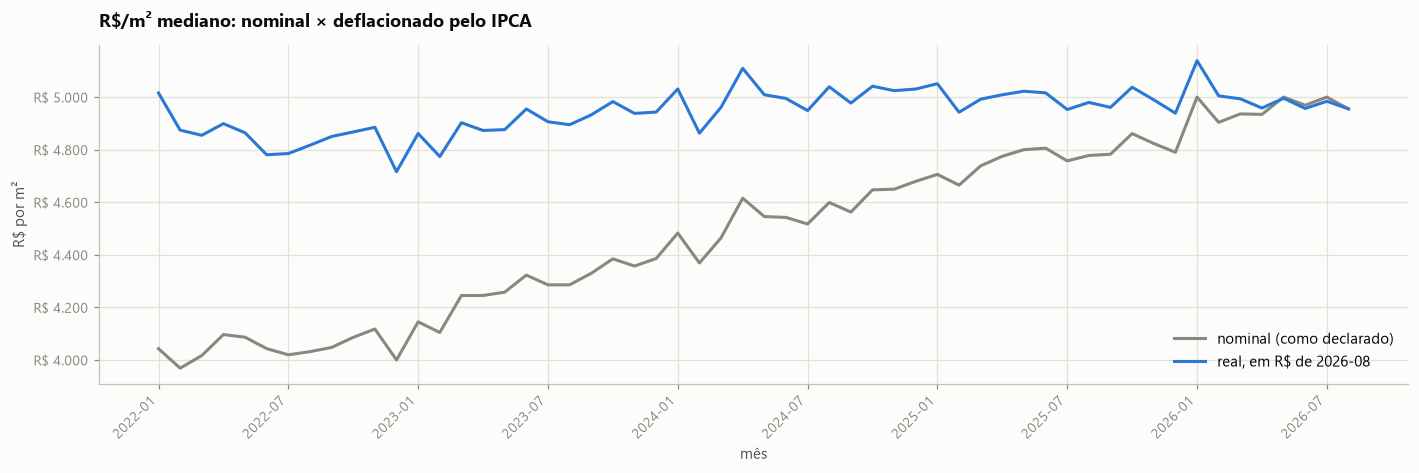

In [9]:
comparativo = base.groupby("mes").agg(nominal=("preco_m2_nominal", "median"),
                                      real=("preco_m2", "median"))

fig, eixo = plt.subplots(figsize=(13, 4.4))
eixo.plot(comparativo.index, comparativo["nominal"], color=MUDO, label="nominal (como declarado)")
eixo.plot(comparativo.index, comparativo["real"], color=AZUL,
          label=f"real, em R$ de {MES_REFERENCIA}")
eixo.set(title="R$/m² mediano: nominal × deflacionado pelo IPCA", xlabel="mês", ylabel="R$ por m²")
eixo.yaxis.set_major_formatter(FORMATO_REAIS)
eixo.set_xticks(eixo.get_xticks()[::6])
plt.setp(eixo.get_xticklabels(), rotation=45, ha="right")
eixo.legend(loc="lower right")
plt.tight_layout()

primeiro, ultimo = comparativo.index[0], comparativo.index[-1]
variacao = comparativo.loc[[primeiro, ultimo]].pct_change().iloc[-1] * 100
print(f"Variação do R$/m² mediano de {primeiro} a {ultimo}:")
print(f"  nominal ....... {variacao['nominal']:+.1f}%")
print(f"  real (IPCA) ... {variacao['real']:+.1f}%")

**`preco_m2` daqui em diante é sempre o valor real.**

## 5 · O lado imóvel

Sanidade antes da correlação: distribuição do preço, estabilidade do volume no tempo, preço por tipo de imóvel.

count    353,553
mean       5,434
std        2,713
min           37
25%        3,601
50%        4,948
75%        6,712
max       18,676


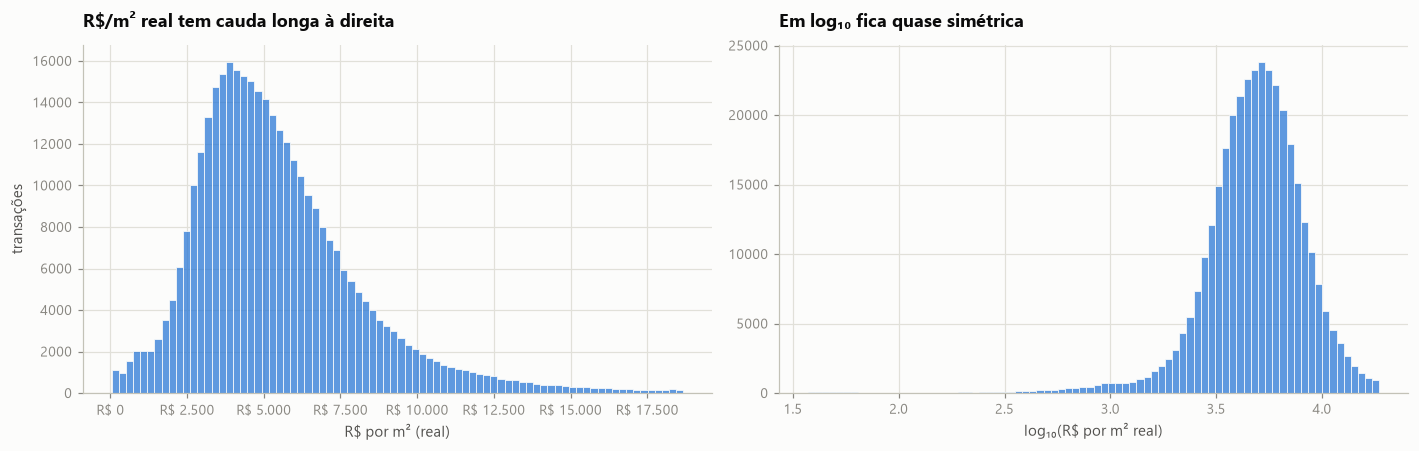

In [10]:
fig, (esq, drt) = plt.subplots(1, 2, figsize=(13, 4.2))

sns.histplot(base["preco_m2"], bins=80, color=AZUL, ax=esq, edgecolor=SUPERFICIE, linewidth=0.5)
esq.set(title="R$/m² real tem cauda longa à direita", xlabel="R$ por m² (real)", ylabel="transações")
esq.xaxis.set_major_formatter(FORMATO_REAIS)

sns.histplot(np.log10(base["preco_m2"]), bins=80, color=AZUL, ax=drt, edgecolor=SUPERFICIE, linewidth=0.5)
drt.set(title="Em log₁₀ fica quase simétrica", xlabel="log₁₀(R$ por m² real)", ylabel="")

plt.tight_layout()

print(base["preco_m2"].describe().apply(lambda v: f"{v:,.0f}").to_string())

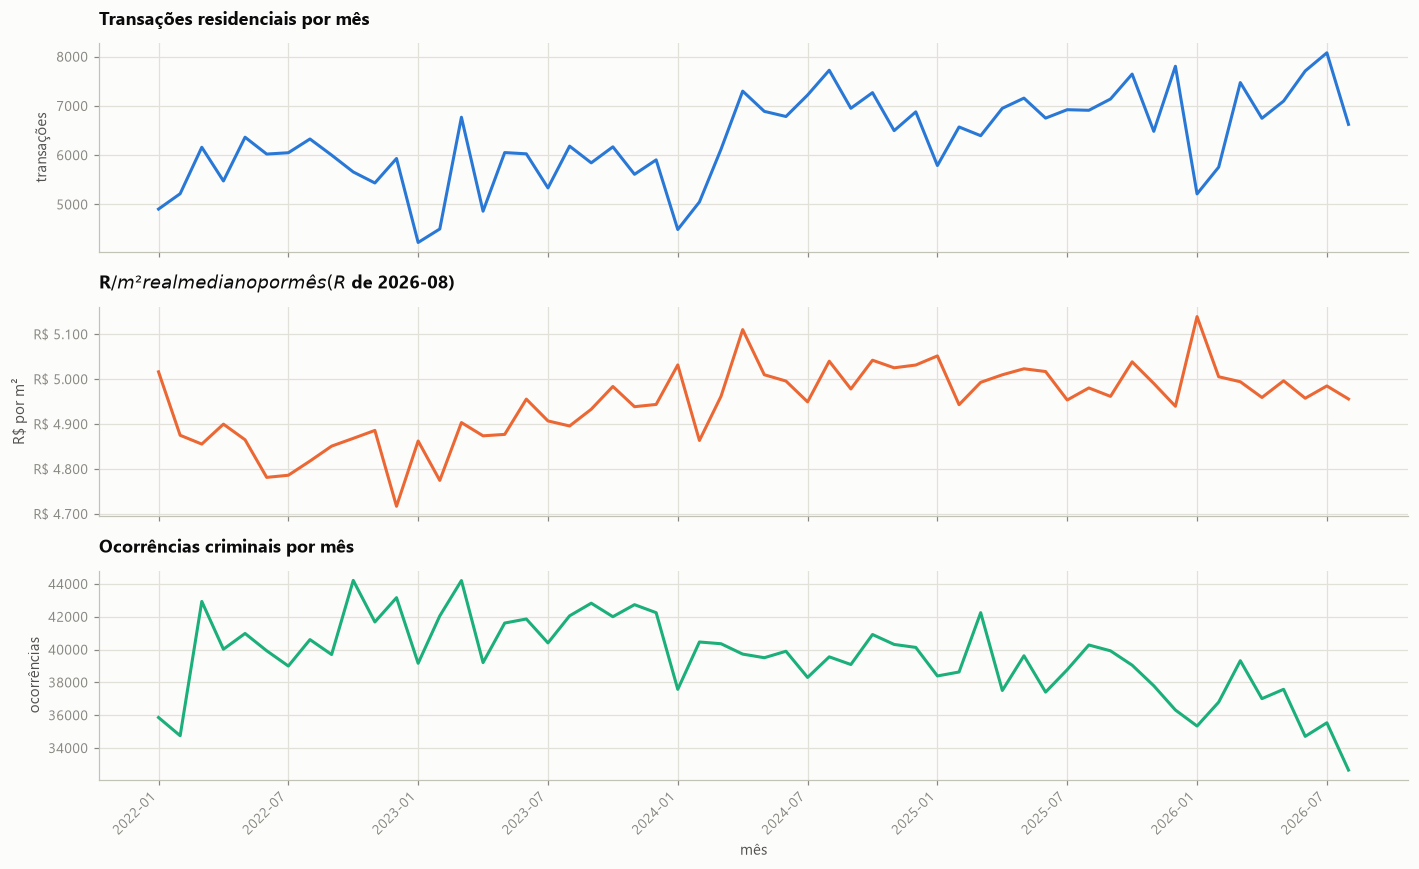

In [11]:
por_mes = base.groupby("mes").agg(transacoes=("preco_m2", "size"), preco_mediano=("preco_m2", "median"))
crimes_mes = crimes.groupby("mes").size()

fig, eixos = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

eixos[0].plot(por_mes.index, por_mes["transacoes"], color=AZUL)
eixos[0].set(title="Transações residenciais por mês", ylabel="transações")

eixos[1].plot(por_mes.index, por_mes["preco_mediano"], color=LARANJA)
eixos[1].set(title=f"R$/m² real mediano por mês (R$ de {MES_REFERENCIA})", ylabel="R$ por m²")
eixos[1].yaxis.set_major_formatter(FORMATO_REAIS)

eixos[2].plot(crimes_mes.index, crimes_mes.to_numpy(), color=AQUA)
eixos[2].set(title="Ocorrências criminais por mês", ylabel="ocorrências", xlabel="mês")

eixos[2].set_xticks(eixos[2].get_xticks()[::6])
plt.setp(eixos[2].get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()

- Painéis separados (não dois eixos y) — dois eixos permitem "escolher" uma correlação só ajustando limites.
- Queda no fim é artefato de 2026 parcial. Taxas anuais de crime usam só **2022–2025**, anos completos.

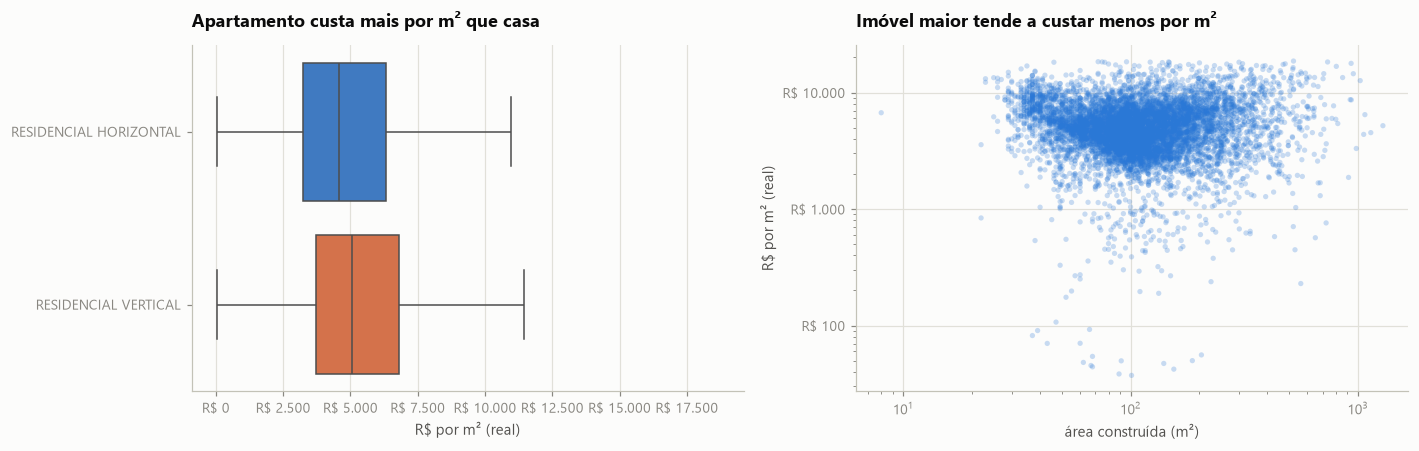

In [12]:
base["tipo"] = base["padrao_desc"].astype(str).str.strip()
recorte = base[base["tipo"].isin(base["tipo"].value_counts().index[:2])]

fig, (esq, drt) = plt.subplots(1, 2, figsize=(13, 4.2))

sns.boxplot(data=recorte, y="tipo", x="preco_m2", hue="tipo", palette=[AZUL, LARANJA],
            legend=False, fliersize=0, linewidth=1, ax=esq)
esq.set(title="Apartamento custa mais por m² que casa", xlabel="R$ por m² (real)", ylabel="")
esq.xaxis.set_major_formatter(FORMATO_REAIS)

sns.scatterplot(data=base.sample(8000, random_state=42), x="area_construida", y="preco_m2",
                color=AZUL, alpha=0.25, s=12, edgecolor="none", ax=drt)
drt.set(title="Imóvel maior tende a custar menos por m²", xlabel="área construída (m²)",
        ylabel="R$ por m² (real)", xscale="log", yscale="log")
drt.yaxis.set_major_formatter(FORMATO_REAIS)

plt.tight_layout()

## 6 · O lado crime

Qual é a composição das ocorrências e onde elas se concentram.

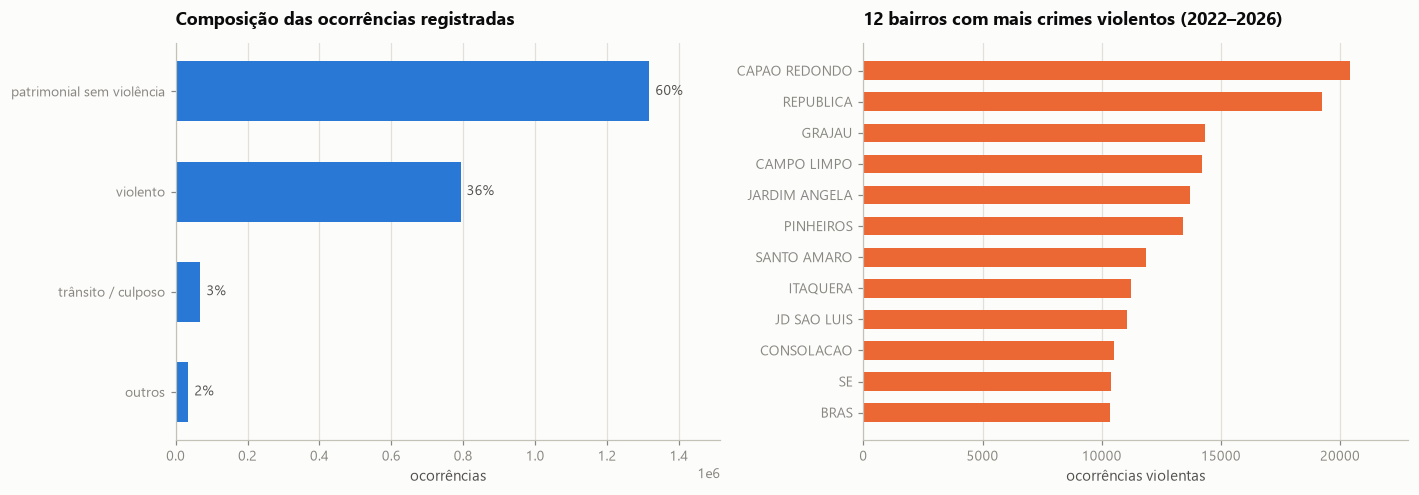

In [13]:
fig, (esq, drt) = plt.subplots(1, 2, figsize=(13, 4.6))

por_grupo = crimes["grupo"].value_counts()
barras = esq.barh(por_grupo.index[::-1], por_grupo.to_numpy()[::-1], color=AZUL, height=0.6)
esq.bar_label(barras, labels=[f"{v / len(crimes):.0%}" for v in por_grupo.to_numpy()[::-1]],
              padding=4, color=TINTA2, fontsize=9)
esq.set(title="Composição das ocorrências registradas", xlabel="ocorrências")
esq.margins(x=0.15)
esq.grid(axis="y", visible=False)

top = crimes[crimes["grupo"] == "violento"]["bairro"].value_counts().head(12)
drt.barh(top.index[::-1].astype(str), top.to_numpy()[::-1], color=LARANJA, height=0.6)
drt.set(title="12 bairros com mais crimes violentos (2022–2026)", xlabel="ocorrências violentas")
drt.margins(x=0.12)
drt.grid(axis="y", visible=False)

plt.tight_layout()

Bairros do topo são polos comerciais com grande circulação — contagem bruta mede **exposição**, não só risco. Por isso a seção 8 testa 4 medidas, não só a contagem.

## 7 · Os dois mapas

- Esquerda: densidade de ocorrências (escala log). Direita: mediana do R$/m² (mínimo 10 transações por hexágono).
- Hipótese ingênua preveria manchas escuras de um mapa sobre claras do outro — a seção 9 explica por que não é bem isso.

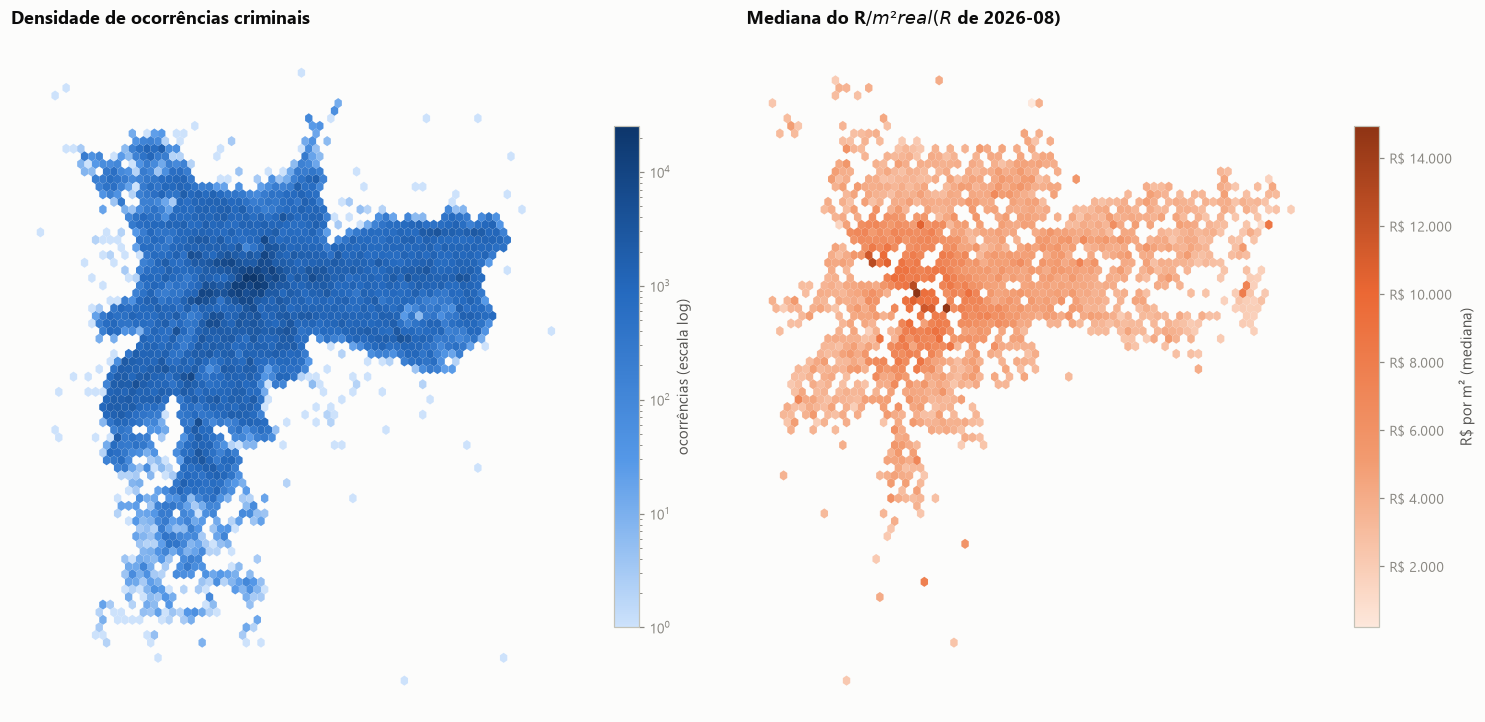

In [14]:
geo_crimes = crimes.dropna(subset=["lat", "lon"])
geo_base = base.dropna(subset=["lat", "lon"])

fig, (esq, drt) = plt.subplots(1, 2, figsize=(14, 6.5))

mapa_crime = esq.hexbin(geo_crimes["lon"], geo_crimes["lat"], gridsize=70,
                        bins="log", cmap=RAMPA_CRIME, linewidths=0)
esq.set_title("Densidade de ocorrências criminais")
fig.colorbar(mapa_crime, ax=esq, shrink=0.75, label="ocorrências (escala log)")

mapa_preco = drt.hexbin(geo_base["lon"], geo_base["lat"], C=geo_base["preco_m2"],
                        reduce_C_function=np.median, mincnt=10, gridsize=70,
                        cmap=RAMPA_PRECO, linewidths=0)
drt.set_title(f"Mediana do R$/m² real (R$ de {MES_REFERENCIA})")
fig.colorbar(mapa_preco, ax=drt, shrink=0.75, label="R$ por m² (mediana)", format=FORMATO_REAIS)

for eixo in (esq, drt):
    eixo.set(xticks=[], yticks=[], aspect="equal")
    eixo.grid(visible=False)
    for borda in eixo.spines.values():
        borda.set_visible(False)

plt.tight_layout()

## 8 · Agregando por bairro

Bairro: grande o bastante para ter crime e transações, pequeno o bastante pra ter perfil próprio. Preço já em reais constantes → mediana comparável entre bairros.

Quatro medidas de crime:

| medida | o que mede | fraqueza |
|---|---|---|
| crimes totais / ano | volume absoluto | contaminada por fluxo |
| crimes violentos / ano | volume do que assusta | idem, menos |
| % de crimes violentos | **composição** | ignora o nível |
| violentos por mil transações | ajustado pelo estoque | aproximação grosseira de população |

- Se as quatro convergem, resultado é robusto; se divergem, a divergência é informativa.
- Descarta bairros com < 30 transações ou < 30 ocorrências (ruído). `log₁₀(1+x)` evita `-inf`.

In [15]:
ANOS_COMPLETOS = [2022, 2023, 2024, 2025]

por_bairro_grupo = (
    crimes[crimes["ano"].isin(ANOS_COMPLETOS)]
    .groupby(["bairro", "grupo"], observed=True)
    .size()
    .unstack(fill_value=0)
    .div(len(ANOS_COMPLETOS))
)
por_bairro_grupo.index = por_bairro_grupo.index.astype(str)

preco_bairro = base.groupby("bairro").agg(
    preco_m2_mediano=("preco_m2", "median"),
    n_transacoes=("preco_m2", "size"),
    area_mediana=("area_construida", "median"),
    idade_mediana=("idade", "median"),
)

bairros = preco_bairro.join(por_bairro_grupo, how="inner")
bairros["crimes_total"] = bairros[por_bairro_grupo.columns].sum(axis=1)
bairros["violentos"] = bairros["violento"]
bairros["share_violento"] = bairros["violentos"] / bairros["crimes_total"]
bairros["violentos_por_1k"] = bairros["violentos"] / bairros["n_transacoes"] * 1000

bairros = bairros[bairros["n_transacoes"].ge(30) & bairros["crimes_total"].ge(30)]
for coluna in ["crimes_total", "violentos", "violentos_por_1k"]:
    bairros[f"log_{coluna}"] = np.log10(1 + bairros[coluna])

print(f"{len(bairros)} bairros aprovados, cobrindo {bairros['n_transacoes'].sum():,} transações")
bairros.sort_values("preco_m2_mediano", ascending=False).head(8)[
    ["preco_m2_mediano", "n_transacoes", "crimes_total", "violentos", "share_violento"]
].round(2)

431 bairros aprovados, cobrindo 312,248 transações


,preco_m2_mediano,n_transacoes,crimes_total,violentos,share_violento
bairro,,,,,
JARDIM EUROPA,14891.68,120,92.50,29.75,0.32
JARDIM UNIVERSIDADE PINHEIROS,12704.48,50,100.75,24.50,0.24
JARDIM PAULISTANO,12533.68,208,844.25,151.25,0.18
VILA NOVA CONCEICAO,10946.28,1358,636.00,194.25,0.31
JARDINS,9133.19,83,97.50,21.00,0.22
CIDADE JARDIM,9052.89,210,180.75,61.00,0.34
ITAIM BIBI,8750.63,2547,7085.00,2173.00,0.31
VILA BEATRIZ,8643.80,121,45.75,15.50,0.34


## 9 · O teste da hipótese

- Dois cenários: completo, e sem os 7 bairros do centro comercial (fluxo gigante, estoque residencial pequeno) — testa se a correlação é artefato de movimento.
- Pearson (linear) e Spearman (só ordem) — Spearman é o mais confiável, imune a outlier.

In [16]:
CENTRO_COMERCIAL = ["SE", "REPUBLICA", "BOM RETIRO", "BRAS", "SANTA IFIGENIA", "LUZ", "CAMPOS ELISEOS"]

CENARIOS = {
    "completo": bairros,
    "sem o centro comercial": bairros.drop(index=CENTRO_COMERCIAL, errors="ignore"),
}

MEDIDAS = {
    "crimes totais / ano (log)": "log_crimes_total",
    "crimes violentos / ano (log)": "log_violentos",
    "% de crimes que são violentos": "share_violento",
    "violentos por mil transações (log)": "log_violentos_por_1k",
}


def correlacao(dados, coluna):
    pearson = stats.pearsonr(dados[coluna], dados["preco_m2_mediano"])
    spearman = stats.spearmanr(dados[coluna], dados["preco_m2_mediano"])
    return {
        "Pearson r": pearson.statistic,
        "p (Pearson)": pearson.pvalue,
        "Spearman ρ": spearman.statistic,
        "p (Spearman)": spearman.pvalue,
        "bairros": len(dados),
    }


resultados = pd.DataFrame(
    [
        {"cenário": cenario, "medida de crime": medida, **correlacao(dados, coluna)}
        for cenario, dados in CENARIOS.items()
        for medida, coluna in MEDIDAS.items()
    ]
).set_index(["cenário", "medida de crime"])

resultados.style.format({
    "Pearson r": "{:+.3f}", "Spearman ρ": "{:+.3f}",
    "p (Pearson)": "{:.2e}", "p (Spearman)": "{:.2e}",
}).background_gradient(cmap=DIVERGENTE, vmin=-0.6, vmax=0.6, subset=["Pearson r", "Spearman ρ"])

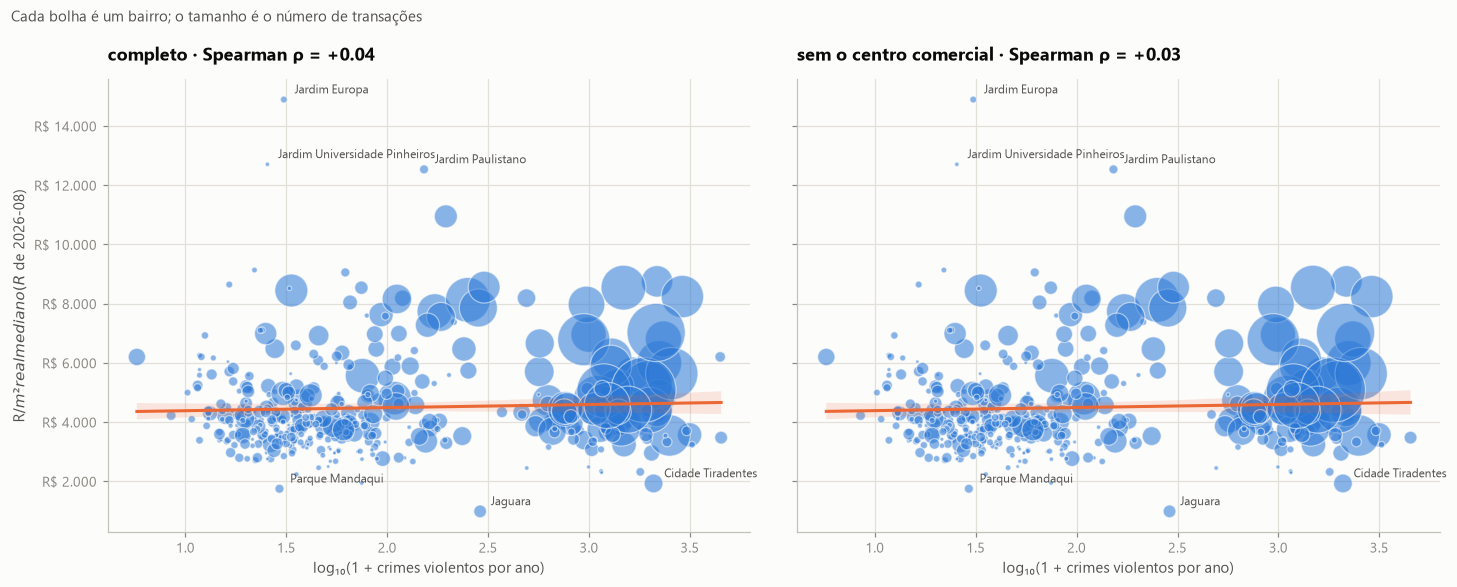

In [17]:
fig, eixos = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)

for eixo, (cenario, dados) in zip(eixos, CENARIOS.items()):
    sns.regplot(
        data=dados, x="log_violentos", y="preco_m2_mediano", ax=eixo,
        scatter_kws={"s": dados["n_transacoes"] / 6, "alpha": 0.55, "color": AZUL,
                     "linewidths": 0.8, "edgecolor": SUPERFICIE},
        line_kws={"color": LARANJA, "linewidth": 2},
    )
    rho = stats.spearmanr(dados["log_violentos"], dados["preco_m2_mediano"]).statistic
    eixo.set(title=f"{cenario} · Spearman ρ = {rho:+.2f}",
             xlabel="log₁₀(1 + crimes violentos por ano)", ylabel="")
    destaques = [*dados["preco_m2_mediano"].nlargest(3).index, *dados["preco_m2_mediano"].nsmallest(3).index]
    for bairro in destaques:
        linha = dados.loc[bairro]
        eixo.annotate(bairro.title(), (linha["log_violentos"], linha["preco_m2_mediano"]),
                      xytext=(7, 4), textcoords="offset points", fontsize=8, color=TINTA2)

eixos[0].set_ylabel(f"R$/m² real mediano (R$ de {MES_REFERENCIA})")
eixos[0].yaxis.set_major_formatter(FORMATO_REAIS)
fig.suptitle("Cada bolha é um bairro; o tamanho é o número de transações",
             x=0.01, ha="left", color=TINTA2, fontsize=10)
plt.tight_layout()

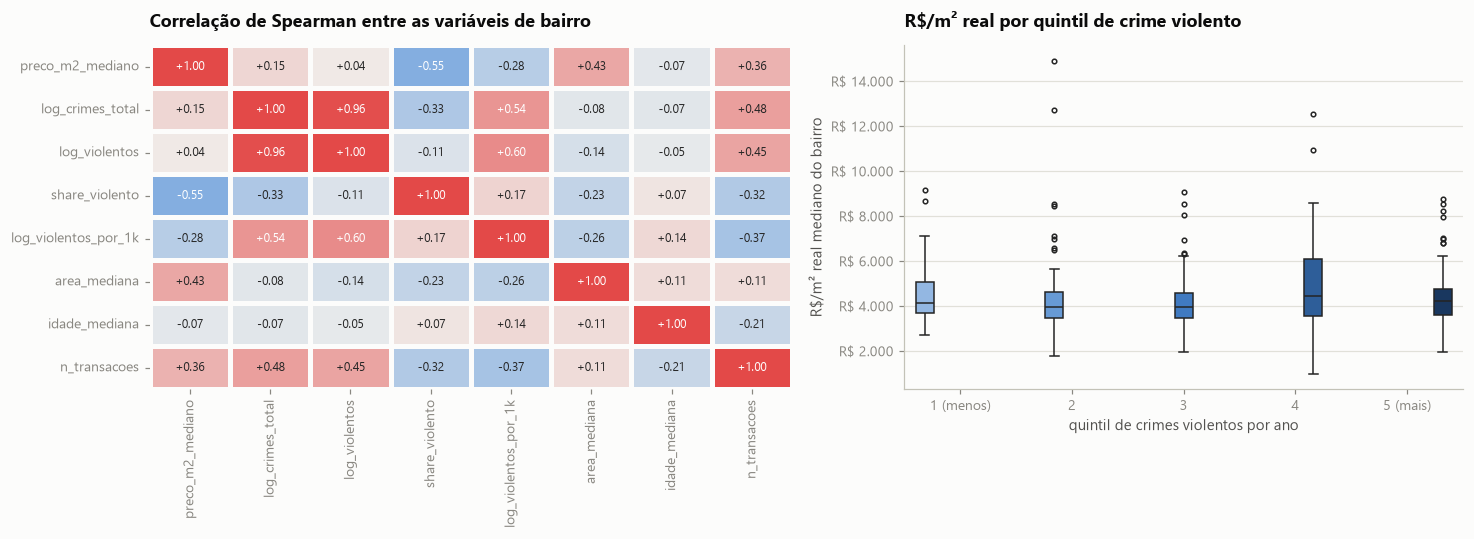

In [18]:
fig, (esq, drt) = plt.subplots(1, 2, figsize=(13.5, 5), width_ratios=[1.15, 1])

colunas = ["preco_m2_mediano", "log_crimes_total", "log_violentos", "share_violento",
           "log_violentos_por_1k", "area_mediana", "idade_mediana", "n_transacoes"]
sns.heatmap(bairros[colunas].corr(method="spearman"), cmap=DIVERGENTE, vmin=-1, vmax=1,
            annot=True, fmt="+.2f", annot_kws={"size": 8}, linewidths=2,
            linecolor=SUPERFICIE, cbar=False, ax=esq)
esq.set_title("Correlação de Spearman entre as variáveis de bairro")

quintis = pd.qcut(bairros["log_violentos"], 5, labels=["1 (menos)", "2", "3", "4", "5 (mais)"])
sns.boxplot(x=quintis, y=bairros["preco_m2_mediano"], hue=quintis, palette=ESCADA_AZUL,
            legend=False, fliersize=3, linewidth=1, ax=drt)
drt.set(title="R$/m² real por quintil de crime violento",
        xlabel="quintil de crimes violentos por ano", ylabel="R$/m² real mediano do bairro")
drt.yaxis.set_major_formatter(FORMATO_REAIS)

plt.tight_layout()

### O que os números dizem

A hipótese se confirma — **mas na composição, não na contagem**. 430 bairros:

| medida de crime | Spearman ρ | p-valor | leitura |
|---|---|---|---|
| crimes totais / ano | +0,146 | 0,0025 | levemente positiva |
| crimes violentos / ano | +0,036 | 0,46 | nenhuma relação |
| **% de crimes violentos** | **−0,548** | 4,5×10⁻³⁵ | forte e negativa |
| violentos por mil transações | −0,296 | 4,0×10⁻¹⁰ | moderada e negativa |

**Quantidade de crime não prevê preço — se algo, bairro caro tem mais crime. A natureza do crime, sim.**

| quintil de % violento | R$/m² mediano |
|---|---|
| 1 (menos) | R$ 5.019 |
| 2 | R$ 4.363 |
| 3 | R$ 4.018 |
| 4 | R$ 3.904 |
| 5 (mais) | **R$ 3.480** |

Queda de 31%, sem inversão no caminho.

- Jardim Paulistano: 844 ocorrências/ano, R$ 12,5 mil/m², só 18% violentas (furto/comércio). Cidade Tiradentes: 3.976/ano, R$ 1,9 mil/m², 52% violentas.
- Remover o centro comercial quase não muda ρ (−0,548 → −0,554) — não é artefato de fluxo.
- As duas medidas normalizadas por exposição concordam entre si; as duas brutas concordam em não achar nada.

## 10 · Base para a modelagem

Perfil criminal do bairro (média 2022–2025, estático — hipótese é espacial, não temporal) colado em cada transação. `base_modelagem.parquet` e `bairros.parquet` gravados pro notebook 03 não repetir tratamento.

In [19]:
COLUNAS_CRIME = ["crimes_total", "violentos", "share_violento", "violentos_por_1k"]

modelagem = base.merge(bairros[COLUNAS_CRIME], left_on="bairro", right_index=True, how="inner")
modelagem.attrs["mes_referencia"] = MES_REFERENCIA
modelagem.to_parquet(CACHE / "base_modelagem.parquet", index=False)
bairros.to_parquet(CACHE / "bairros.parquet")
(CACHE / "mes_referencia.txt").write_text(MES_REFERENCIA, encoding="utf-8")

print(f"base_modelagem: {len(modelagem):,} transações × {modelagem.shape[1]} colunas")
print(f"bairros:        {len(bairros):,} bairros")
print(f"preços em reais constantes de {MES_REFERENCIA}")

base_modelagem: 312,248 transações × 40 colunas
bairros:        431 bairros
preços em reais constantes de 2026-08


## 11 · Ressalvas

- **Crime registrado ≠ crime ocorrido.** Renda mais alta tende a registrar mais — se forte, isso *atenuaria* a correlação negativa, não criaria.
- **Contagem mede exposição, não só risco.** Sem taxa por habitante (população disponível no repo é do Rio, não de SP).
- **Valor é autodeclarado** — incentivo a subdeclarar. Uniforme pela cidade não afeta a correlação; concentrado em algum tipo de bairro, enviesa.
- **Seleção pelo dicionário de ruas** remove parte do extremo "pouco crime" — tende a **atenuar** a correlação.
- **Correlação não é causalidade.** Renda pode ser causa comum. Notebook 03 controla por características do imóvel (parcial, não experimento).
- IPCA é índice nacional — não corrige dinâmica imobiliária de SP especificamente, mas a correção é igual pra todos os bairros no mesmo mês, então não afeta a comparação entre eles.

➡️ Próximo: `03_modelagem.ipynb`.